In [412]:
## Check potential against the House paper and HOA-2 trap paper
import constants as c
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

## Constants
Z_charge = c.Z
e = c.e
um = c.um
omega = c.omega
vrf = c.vrf
m = c.m
z0 = c.z0

## Region of interest
res = 1*c.um; # resolution of potential 
x_max = 100*c.um;
y_max = 100*c.um;
z_max = 200*c.um;
x = np.linspace(-1*x_max,x_max, int(2*x_max/res+1), endpoint=True); # -1cm<=x<=1cm 
y = np.linspace(-1*y_max,y_max, int(2*y_max/res+1), endpoint=True);  # -1cm<=y<=1cm
z = np.linspace(0,z_max, int(z_max/res+1), endpoint=True);  # 0cm<=z<=1cm

## Zoomed potential files, -100<x<100um,-100<y<100um,0<z<200um
original_shape_3d = (201,201,201)
phi_dc_flat = np.loadtxt('dc_potential_zoomed')
phi_rf_flat = np.loadtxt('rf_potential_max_zoomed')
pseudo_flat = np.loadtxt('pseudo_potential_zoomed')
phi_dc = phi_dc_flat.reshape(original_shape_3d)
phi_rf = phi_rf_flat.reshape(original_shape_3d)
pseudo = pseudo_flat.reshape(original_shape_3d)
energy_tot = e*phi_dc+pseudo

## Helper Functions

In [413]:
# finds local minimum of a 1D array
def find_local_extrema(phi_sliced: np.ndarray):
    delta_phi = [0]
    min_coord = []
    min_val = []
    max_coord = []
    max_val = []
    for i in range(1,len(phi_sliced)):
        delta_phi.append(phi_sliced[i]-phi_sliced[i-1])
        prod = delta_phi[i]*delta_phi[i-1]
        if (prod<0 and delta_phi[i-1]<0):
            min_coord.append(i-1)
            min_val.append(phi_sliced[i-1])
        elif (prod<0 and delta_phi[i-1]>0):
            max_coord.append(i-1)
            max_val.append(phi_sliced[i-1])
    return min_coord,min_val,max_coord,max_val

In [414]:
# checks uniformity in 2D array, returns the value of the elements and their occurences
def check_uniformity(phi_sliced: np.ndarray):
    prev_val = 10000
    elements = []
    x_index = []
    y_index = []
    for i in range(len(phi_sliced)):
        for j in range(len(phi_sliced[i])):
            if (phi_sliced[i][j] != prev_val) and (not np.isnan(phi_sliced[i][j])):
                elements.append(phi_sliced[i][j])
                x_index.append(i)
                y_index.append(j)
                prev_val = phi_sliced[i][j]
    return elements,x_index,y_index


In [415]:
# Helper function: fit 1D potential to a quadratic
def fit_quadratic(y_vec,y0,energy_vec):
    min_energy = energy_vec[10]
    def quadratic(y_val,A):
        return A*(y_val-y0)**2 + min_energy
    popt, cov = curve_fit(quadratic,y_vec,energy_vec)
    #print(popt)
    # Calculate residuals
    residuals = energy_vec - quadratic(y_vec, *popt)
    ssr = np.sum(residuals**2)
    sst = np.sum((energy_vec - np.mean(energy_vec))**2)
    r_squared = 1 - (ssr / sst)
    #print(f"R-squared: {r_squared:.4f}")
    k = popt[0]*2
    f_trap = np.sqrt(k/c.m)/(2*math.pi)
    return k,f_trap  

In [416]:
# Helper function: fit potential to 3D surface
def fit_3d(x_mesh,y_mesh,z_mesh,z_min,energy_sample: np.ndarray): # takes in 21*21*21 array
    index = int(len(energy_sample)/2)
    min_energy = energy_sample[index,index,index]
    def surface_1(mesh,A,B,C,D,E,F,G,H,I):
        x_val,y_val,z_val = mesh
        return A*x_val**2 + B*y_val**2 + C*(z_val-z_min)**2 + D*x_val*y_val + E*x_val*(z_val-z_min) + F*y_val*(z_val-z_min) + G*x_val + H*y_val + I*(z_val-z_min) + min_energy
    def surface_2(mesh,A,B,C,D,E,F):
        x_val,y_val,z_val = mesh
        return A*x_val**2 + B*y_val**2 + C*(z_val-z_min)**2 + D*x_val*y_val + E*x_val*(z_val-z_min) + F*y_val*(z_val-z_min) + min_energy
    def surface_3(mesh,A,B,C):
        x_val,y_val,z_val = mesh
        return A*x_val**2 + B*y_val**2 + C*(z_val-z_min)**2 + min_energy
    x_mesh_flat = x_mesh.flatten()
    y_mesh_flat = y_mesh.flatten()
    z_mesh_flat = z_mesh.flatten()
    energy_sample_flat = energy_sample.flatten()
    
    # Calculate residuals
    popt_1, cov_1 = curve_fit(surface_1,(x_mesh_flat,y_mesh_flat,z_mesh_flat),energy_sample_flat)
    residuals_1 = energy_sample - surface_1((x_mesh,y_mesh,z_mesh),*popt_1)
    ssr_1 = np.sum(residuals_1**2)
    sst_1 = np.sum((energy_sample - np.mean(energy_sample))**2)
    r_squared_1 = 1 - (ssr_1/sst_1)
    print(f"Fit equation option 1: {popt_1[0]}x^2 + {popt_1[1]}*y^2 + {popt_1[2]}*(z - {z_min})^2 + {popt_1[3]}*xy + {popt_1[4]}*x*(z - {z_min}) + {popt_1[5]}*y*(z - {z_min}) + {popt_1[6]}*x + {popt_1[7]}*y + {popt_1[8]}*(z - {z_min}) + {min_energy}")
    print(f"R-squared option 1: {r_squared_1}")
    popt_2, cov_2 = curve_fit(surface_2,(x_mesh_flat,y_mesh_flat,z_mesh_flat),energy_sample_flat)
    residuals_2 = energy_sample - surface_2((x_mesh,y_mesh,z_mesh),*popt_2)
    ssr_2 = np.sum(residuals_2**2)
    sst_2 = np.sum((energy_sample - np.mean(energy_sample))**2)
    r_squared_2 = 1 - (ssr_2/sst_2)
    print(f"Fit equation option 2: {popt_2[0]}x^2 + {popt_2[1]}*y^2 + {popt_2[2]}*(z - {z_min})^2 + {popt_2[3]}*xy + {popt_2[4]}*x*(z - {z_min}) + {popt_2[5]}*y*(z - {z_min}) + {min_energy}")
    print(f"R-squared option 2: {r_squared_2}")
    popt_3, cov_3 = curve_fit(surface_3,(x_mesh_flat,y_mesh_flat,z_mesh_flat),energy_sample_flat)
    residuals_3 = energy_sample - surface_3((x_mesh,y_mesh,z_mesh),*popt_3)
    ssr_3 = np.sum(residuals_3**2)
    sst_3 = np.sum((energy_sample - np.mean(energy_sample))**2)
    r_squared_3 = 1 - (ssr_3/sst_3)
    print(f"Fit equation option 3: {popt_3[0]}x^2 + {popt_3[1]}*y^2 + {popt_3[2]}*(z - {z_min})^2 + {min_energy}")
    print(f"R-squared option 3: {r_squared_3}")
    return popt_1,popt_2,popt_3


## Sanity check: RF Potential

In [417]:
## 1. z-coordinate of ion location (minimum of peak RF potential)
# House theory (eq.26)
a = 59.4*um; # central slot width gap_rf
b = 135.3*um; # rf electrode width wrf_new
z_min_theory = math.sqrt(2*a*b+a**2)/2
# Calculation
phi_rf_z_axis = phi_rf[100,100,:]
z_min_calc,min_pot = find_local_extrema(phi_rf_z_axis)[2],find_local_extrema(phi_rf_z_axis)[3]
print(f"Theoretical minimum trap potential is at z={z_min_theory/um} um")
print(f"Calculated minimum trap potential is at z={z_min_calc[0]} um")

Theoretical minimum trap potential is at z=70.00357133746822 um
Calculated minimum trap potential is at z=70 um


In [418]:
## 2. z-coordinate of escape point (saddle point of pseudopotential)
# House theory Sec IV p.5
z_saddle_theory = math.sqrt(2*a*b+a**2+2*(a+b)*math.sqrt(2*a*b+a**2))/2
# Calculation
pseudo_z_axis = pseudo[100,100,:]
z_saddle_calc,saddle_val = find_local_extrema(pseudo_z_axis)[2],find_local_extrema(pseudo_z_axis)[3]
print(f"Theoretical saddle point of pseudopotential is at z={z_saddle_theory/um} um")
print(f"Calculated saddle point of pseudopotential is at z={z_saddle_calc[0]} um")

Theoretical saddle point of pseudopotential is at z=136.12566010640705 um
Calculated saddle point of pseudopotential is at z=136 um


In [419]:
## 3. Trap depth (pseudopotential at escape point)
# House eq.28
trap_depth_theory = ((Z_charge*e*vrf)**2/(math.pi**2*m*omega**2))*(b/((a+b)**2+(a+b)*math.sqrt(a**2+2*a*b)))**2
# Calculation
trap_depth_calc = pseudo_z_axis[z_saddle_calc[0]]-pseudo_z_axis[z_min_calc[0]]
print(f"Theoretical trap depth is {trap_depth_theory} J")
print(f"Calculated trap depth is {trap_depth_calc} J")

Theoretical trap depth is 2.1277368514327223e-20 J
Calculated trap depth is 2.127731169601618e-20 J


## Total Energy and Estimation of Secular Frequencies

In [420]:
## 1. Location and magnitude of minimum energy (should be 68um)
# Ion height: 80um when wrf = 110um, 94um when wrf = 140um, 
energy_tot_z_axis = energy_tot[100,100,:]
z_min_energy,min_energy = find_local_extrema(energy_tot_z_axis)[0],find_local_extrema(energy_tot_z_axis)[1]
print(f"Local minimum of total energy is at z={z_min_energy[0]} um while it should be at 70 um")
print(f"Minimum energy is {min_energy[0]} J")

Local minimum of total energy is at z=70 um while it should be at 70 um
Minimum energy is 2.016615217832247e-20 J


In [421]:
## 2. Quadratic fit of energy along the x,y,z axes
# x-coord, y=0, z=z_min_energy
energy_x = energy_tot[:,100,z_min_energy[0]][90:111]
x_small = x[90:111]
print("x-axis energy values:")
print(energy_x)
kx,f_trap_x = fit_quadratic(x_small,0,energy_x)
print(f"For the x-axis, the trap coefficient is {kx} J/m^2 and the trap frequency is {f_trap_x} Hz")

# y-coord, x=0, z=z_min_energy
energy_y = energy_tot[100,:,z_min_energy[0]][90:111]
y_small = y[90:111]
print("y-axis energy values:")
print(energy_y)
ky,f_trap_y = fit_quadratic(y_small,0,energy_y)
print(f"For the y-axis, the trap coefficient is {ky} J/m^2 and the trap frequency is {f_trap_y} Hz")

# z-axis
energy_z = energy_tot[100,100,:][(z_min_energy[0]-10):(z_min_energy[0]+11)]
z_small = z[(z_min_energy[0]-10):(z_min_energy[0]+11)]
print("z-axis energy values:")
print(energy_z)
kz,f_trap_z = fit_quadratic(z_small,z_min_energy[0]*um,energy_z)
print(f"For the z-axis, the trap coefficient is {kz} J/m^2 and the trap frequency is {f_trap_z} Hz")


x-axis energy values:
[2.04564077e-20 2.04012377e-20 2.03518850e-20 2.03083426e-20
 2.02706129e-20 2.02386910e-20 2.02125747e-20 2.01922638e-20
 2.01777560e-20 2.01690537e-20 2.01661522e-20 2.01690537e-20
 2.01777560e-20 2.01922638e-20 2.02125747e-20 2.02386910e-20
 2.02706129e-20 2.03083426e-20 2.03518850e-20 2.04012377e-20
 2.04564077e-20]
For the x-axis, the trap coefficient is 5.804512017331327e-12 J/m^2 and the trap frequency is 719582.1548601933 Hz
y-axis energy values:
[2.51276505e-20 2.41963747e-20 2.33586080e-20 2.26158467e-20
 2.19694175e-20 2.14204730e-20 2.09699942e-20 2.06187836e-20
 2.03674710e-20 2.02165032e-20 2.01661522e-20 2.02165032e-20
 2.03674710e-20 2.06187836e-20 2.09699942e-20 2.14204730e-20
 2.19694175e-20 2.26158467e-20 2.33586080e-20 2.41963747e-20
 2.51276505e-20]
For the y-axis, the trap coefficient is 9.955523709072657e-11 J/m^2 and the trap frequency is 2980091.3902219213 Hz
z-axis energy values:
[2.76237554e-20 2.58875267e-20 2.44402232e-20 2.32516664e-2

In [422]:
## 3. Estimate of trap secular frequency
# HOA-2 Trap p.24
R = 140*um
omega_sec = e*c.vrf_original/(math.sqrt(2)*omega*m*R**2); # assuming the original RF peak value of 250V
print(f"Trap secular frequency is estimated to be {omega_sec*um/(2*math.pi)}*2pi*10^6 rad/s")

Trap secular frequency is estimated to be 3.5758679760081966*2pi*10^6 rad/s


In [423]:
## 4. Location of escape point and trap depth
# HOA-2 Trap p.24
alpha = 0.028
trap_depth_theory = (alpha*0.5*m*omega_sec**2*R**2/e)*1000
# Calculation
z_escape, energy_escape = find_local_extrema(energy_tot_z_axis)[2],find_local_extrema(energy_tot_z_axis)[3]
trap_depth = (energy_escape[0])/e
print(f"Escape point of total energy is at z={z_escape[0]} um")
print(f"Energy at the escape point is {energy_escape[0]} J")
print(f"Trap depth is {trap_depth*1000} meV while it should be {trap_depth_theory} meV")

Escape point of total energy is at z=127 um
Energy at the escape point is 3.904939356169012e-20 J
Trap depth is 244.05870976056323 meV while it should be 245.82838140614547 meV


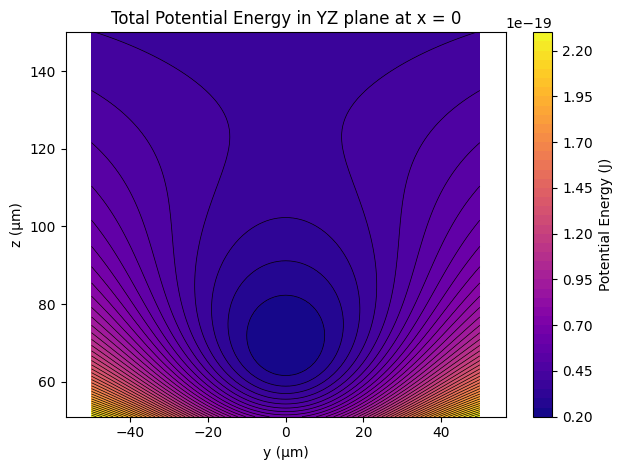

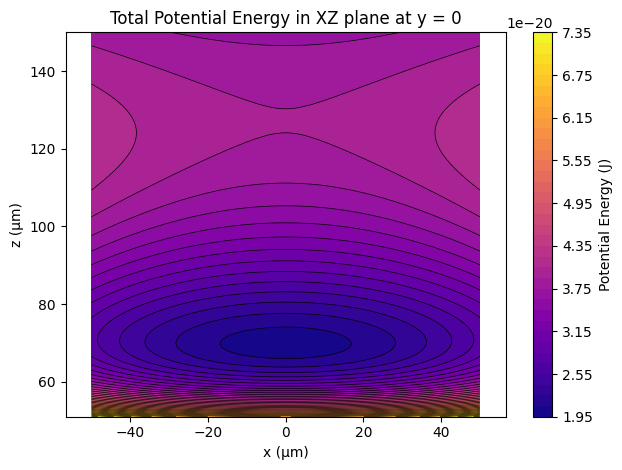

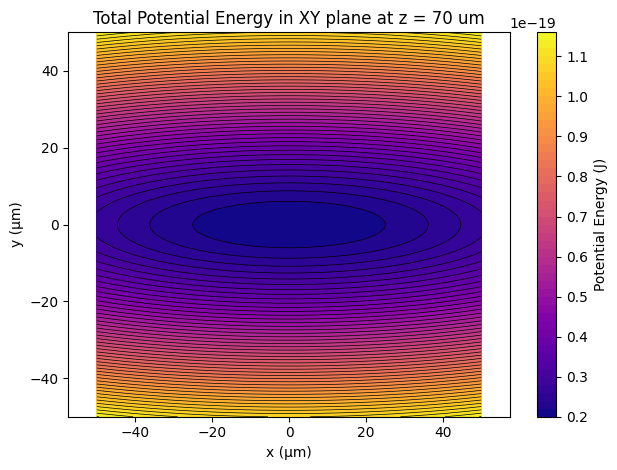

In [424]:
## 5. Graph

## Graph of total potential energy (zoomed)
# plane x=0

y_mask = (y >= -50e-6) & (y <= 50e-6)
z_mask = (z >= 50e-6) & (z <= 150e-6)
y_subset = y[y_mask]
z_subset = z[z_mask]
energy_tot_subset = energy_tot[100, :, :][y_mask, :][:, z_mask]

Y, Z = np.meshgrid(y_subset, z_subset, indexing='ij')

plt.figure()
cf = plt.contourf(Y/um, Z/um, energy_tot_subset, levels=50, cmap='plasma')
plt.contour(Y/um, Z/um, energy_tot_subset, levels=50, colors='k', linewidths=0.5)
plt.colorbar(cf,label='Potential Energy (J)')
plt.xlabel('y (μm)')
plt.ylabel('z (μm)')
plt.title(f'Total Potential Energy in YZ plane at x = 0')
plt.axis('equal')
plt.tight_layout()
plt.show()

# plane y=0

x_mask = (x >= -50e-6) & (x <= 50e-6)
z_mask = (z >= 50e-6) & (z <= 150e-6)
x_subset = x[x_mask]
z_subset = z[z_mask]
energy_tot_subset = energy_tot[:, 100, :][x_mask, :][:, z_mask]

X, Z = np.meshgrid(x_subset, z_subset, indexing='ij')

plt.figure()
cf = plt.contourf(X/um, Z/um, energy_tot_subset, levels=50, cmap='plasma')
plt.contour(X/um, Z/um, energy_tot_subset, levels=50, colors='k', linewidths=0.5)
plt.colorbar(cf,label='Potential Energy (J)')
plt.xlabel('x (μm)')
plt.ylabel('z (μm)')
plt.title(f'Total Potential Energy in XZ plane at y = 0')
plt.axis('equal')
plt.tight_layout()
plt.show()

# plane z=70 um

x_mask = (x >= -50e-6) & (x <= 50e-6)
y_mask = (y >= -50e-6) & (y <= 50e-6)
x_subset = x[x_mask]
y_subset = y[y_mask]
energy_tot_subset = energy_tot[:, :, 70][x_mask, :][:, y_mask]

X, Y = np.meshgrid(x_subset, y_subset, indexing='ij')

plt.figure()
cf = plt.contourf(X/um, Y/um, energy_tot_subset, levels=50, cmap='plasma')
plt.contour(X/um, Y/um, energy_tot_subset, levels=50, colors='k', linewidths=0.5)
plt.colorbar(cf,label='Potential Energy (J)')
plt.xlabel('x (μm)')
plt.ylabel('y (μm)')
plt.title(f'Total Potential Energy in XY plane at z = 70 um')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Quadratic Fit for DC, RF, and Total Energy

In [425]:
## Check DC alignment
phi_dc_z_axis = phi_dc[100,100,:]
z_saddle_dc,saddle_dc_pot = find_local_extrema(phi_dc_z_axis)[2],find_local_extrema(phi_dc_z_axis)[3]

phi_dc_x_axis = phi_dc[:,100,z_saddle_dc[0]]
phi_dc_y_axis = phi_dc[100,:,z_saddle_dc[0]]

print(f"Saddle point of DC potential is at z={z_saddle_dc[0]} um")
print(f"DC potential at saddle point is {saddle_dc_pot[0]} V")
# print(phi_dc_x_axis)
# print(phi_dc_y_axis)
# print(phi_dc_z_axis)

Saddle point of DC potential is at z=80 um
DC potential at saddle point is 0.12705552577972412 V


In [426]:
## Total energy fit: ensure symmetry about trap center
# Fit with 21*21*21
print("Fit with 21*21*21 data points:")
x_mesh_small = np.zeros((21,21,21))
y_mesh_small = np.zeros((21,21,21))
z_mesh_small = np.zeros((21,21,21))
z_mesh_small_dc = np.zeros((21,21,21))
for i in range (0,21):
    for j in range (0,21):
        for k in range (0,21):
            x_mesh_small[i][j][k] = x[i+90]
            y_mesh_small[i][j][k] = y[j+90]
            z_mesh_small[i][j][k] = z[k+z_min_energy[0]-10]
            z_mesh_small_dc[i][j][k] = z[k+z_saddle_dc[0]-10]
energy_sample_small = energy_tot[90:111,90:111,(z_min_energy[0]-10):(z_min_energy[0]+11)]
phi_3d_fit = fit_3d(x_mesh_small,y_mesh_small,z_mesh_small,z_min_energy[0]*um, energy_sample_small)

# Fit with 11*11*11
print("Fit with 11*11*11 data points:")
x_mesh_extra_small = np.zeros((11,11,11))
y_mesh_extra_small = np.zeros((11,11,11))
z_mesh_extra_small = np.zeros((11,11,11))
z_mesh_extra_small_dc = np.zeros((11,11,11))
for i in range (0,11):
    for j in range (0,11):
        for k in range (0,11):
            x_mesh_extra_small[i][j][k] = x[i+95]
            y_mesh_extra_small[i][j][k] = y[j+95]
            z_mesh_extra_small[i][j][k] = z[k+z_min_energy[0]-5]
            z_mesh_extra_small_dc[i][j][k] = z[k+z_saddle_dc[0]-5]
energy_sample_extra_small = energy_tot[95:106,95:106,(z_min_energy[0]-5):(z_min_energy[0]+6)]
phi_3d_fit = fit_3d(x_mesh_extra_small,y_mesh_extra_small,z_mesh_extra_small,z_min_energy[0]*um, energy_sample_extra_small)

Fit with 21*21*21 data points:
Fit equation option 1: 2.090009338713521e-12x^2 + 5.0553157621887764e-11*y^2 + 5.558343464343278e-11*(z - 7e-05)^2 + 9.08255604098408e-19*xy + -7.128581919318342e-19*x*(z - 7e-05) + -4.519273811954626e-18*y*(z - 7e-05) + -1.3448903031269472e-24*x + 1.6226790381121438e-24*y + -1.9811739455366756e-16*(z - 7e-05) + 2.016615217832247e-20
R-squared option 1: 0.9552251259374682
Fit equation option 2: 2.0899973166516735e-12x^2 + 5.055315633547823e-11*y^2 + 5.5583447916813655e-11*(z - 7e-05)^2 + 1.6761613633547373e-18*xy + 6.911850888141032e-18*x*(z - 7e-05) + 9.571801935447696e-18*y*(z - 7e-05) + 2.016615217832247e-20
R-squared option 2: 0.7757716732915952
Fit equation option 3: 2.0900092404004146e-12x^2 + 5.0553157631044046e-11*y^2 + 5.5583434677449854e-11*(z - 7e-05)^2 + 2.016615217832247e-20
R-squared option 3: 0.7757716732916621
Fit with 11*11*11 data points:
Fit equation option 1: 2.685588685963986e-12x^2 + 5.042684962472347e-11*y^2 + 5.1053935604014984e-11

In [427]:
## Compute Aij: phi_dc fit
A = np.zeros((3,3))

print("\nPotential expanded at z_dc")
# Saddle point at (0,0,z_saddle_dc)
# Fit with 11*11*11
print("Fit with 11*11*11 data points:")
z_dc = z_saddle_dc[0]
phi_dc_extra_small = 1e-20*phi_dc[95:106,95:106,(z_dc-5):(z_dc+6)]
phi_dc_3d = fit_3d(x_mesh_extra_small,y_mesh_extra_small,z_mesh_extra_small_dc,z_dc*um, phi_dc_extra_small)
# Aij = 4Ze/(m*omega^2)*(dphi/dxidxj)
"""
for i in range(0,3):
    A[i][i] = 1e20*(4*Z_charge*e/(m*omega**2))*(phi_dc_3d[0][i]); # fit with option 1
print(f"\nStability parameters A: \n{A}")
"""
# Fit with 21*21*21
print("\nFit with 21*21*21 data points:")
phi_dc_small = 1e-20*phi_dc[90:111,90:111,(z_dc-10):(z_dc+11)]
phi_dc_3d = fit_3d(x_mesh_small,y_mesh_small,z_mesh_small_dc,z_dc*um, phi_dc_small)

print("\nPotential expanded at z_energy_min")
# Saddle point at (0,0,z_saddle_dc)
# Fit with 11*11*11
print("Fit with 11*11*11 data points:")
phi_dc_extra_small = 1e-20*phi_dc[95:106,95:106,(z_min_energy[0]-5):(z_min_energy[0]+6)]
phi_dc_3d = fit_3d(x_mesh_extra_small,y_mesh_extra_small,z_mesh_extra_small_dc,z_min_energy[0]*um, phi_dc_extra_small)
# Aij = 4Ze/(m*omega^2)*(dphi/dxidxj)
"""
for i in range(0,3):
    A[i][i] = 1e20*(4*Z_charge*e/(m*omega**2))*(phi_dc_3d[0][i]); # fit with option 1
print(f"\nStability parameters A: \n{A}")
"""
# Fit with 21*21*21
print("\nFit with 21*21*21 data points:")
phi_dc_small = 1e-20*phi_dc[90:111,90:111,(z_min_energy[0]-10):(z_min_energy[0]+11)]
phi_dc_3d = fit_3d(x_mesh_small,y_mesh_small,z_mesh_small_dc,z_min_energy[0]*um, phi_dc_small)



Potential expanded at z_dc
Fit with 11*11*11 data points:
Fit equation option 1: 1.545523359883215e-13x^2 + -5.986602029319081e-14*y^2 + -9.464430150926267e-14*(z - 7.999999999999999e-05)^2 + -9.93267105820253e-20*xy + 6.566324492333591e-20*x*(z - 7.999999999999999e-05) + 1.3297837922346301e-20*y*(z - 7.999999999999999e-05) + 2.2399717960813868e-25*x + -1.9201107104676009e-25*y + -2.368676514081038e-20*(z - 7.999999999999999e-05) + 1.2705552577972412e-21
R-squared option 1: 0.9980172640931434
Fit equation option 2: 1.5455231678699825e-13x^2 + -5.986594115356683e-14*y^2 + -9.464427663690926e-14*(z - 7.999999999999999e-05)^2 + -5.437662660479824e-18*xy + -4.2306406934208384e-18*x*(z - 7.999999999999999e-05) + 1.0830226113760573e-17*y*(z - 7.999999999999999e-05) + 1.2705552577972412e-21
R-squared option 2: 0.9960504189827746
Fit equation option 3: 1.545522890042805e-13x^2 + -5.98659679691466e-14*y^2 + -9.464427079395513e-14*(z - 7.999999999999999e-05)^2 + 1.2705552577972412e-21
R-squared

/tmp/ipykernel_4006/2698373240.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_1, cov_1 = curve_fit(surface_1,(x_mesh_flat,y_mesh_flat,z_mesh_flat),energy_sample_flat)


In [428]:
## Compute Qij: phi_rf fit
Q = np.zeros((3,3))
# Fit with 11*11*11
print("Fit with 11*11*11 data points:")
phi_rf_extra_small = 1e-20*phi_rf[95:106,95:106,(z_min_energy[0]-5):(z_min_energy[0]+6)]
phi_rf_3d = fit_3d(x_mesh_extra_small,y_mesh_extra_small,z_mesh_extra_small,z_min_energy[0]*um, phi_rf_extra_small)
# Qij = 2Ze/(m*omega^2)*(dphi/dxidxj)
"""
for i in range(0,3):
    Q[i][i] = 1e20*(2*Z_charge*e/(m*omega**2))*(phi_rf_3d[2][i]); # fit with option 3
print(f"\nStability parameters Q: \n{Q}")
"""
# Fit with 21*21*21
print("Fit with 21*21*21 data points:")
phi_rf_small = 1e-20*phi_rf[90:111,90:111,(z_min_energy[0]-10):(z_min_energy[0]+11)]
phi_rf_3d = fit_3d(x_mesh_small,y_mesh_small,z_mesh_small,z_min_energy[0]*um, phi_rf_small)

Fit with 11*11*11 data points:
Fit equation option 1: -9.934460534461396e-14x^2 + 5.416555899252114e-11*y^2 + -5.3790084307586444e-11*(z - 7e-05)^2 + 1.0401268796050051e-17*xy + 2.0194846247910065e-18*x*(z - 7e-05) + 2.776945856751237e-17*y*(z - 7e-05) + 3.8161367753521123e-23*x + -1.1192925214680342e-22*y + -2.5704716961195052e-17*(z - 7e-05) + 8.121110186781166e-19
R-squared option 1: 0.9902598599433906
Fit equation option 2: -9.935963778843793e-14x^2 + 5.4165492168152055e-11*y^2 + -5.3790050158796336e-11*(z - 7e-05)^2 + 1.4667676016426297e-17*xy + -9.945108339097724e-18*x*(z - 7e-05) + -9.588534144878419e-18*y*(z - 7e-05) + 8.121110186781166e-19
R-squared option 2: 0.976071186385181
Fit equation option 3: -9.934971996568469e-14x^2 + 5.416554671694505e-11*y^2 + -5.3790073490127945e-11*(z - 7e-05)^2 + 8.121110186781166e-19
R-squared option 3: 0.9760711863862781
Fit with 21*21*21 data points:
Fit equation option 1: -3.5477519066909854e-13x^2 + 5.4652979663765894e-11*y^2 + -5.3294968228

In [429]:
## Pseudopotential fit
# Fit with 11*11*11
print("Fit with 11*11*11 data points:")
pseudo_extra_small = pseudo[95:106,95:106,(z_min_energy[0]-5):(z_min_energy[0]+6)]
pseudo_3d = fit_3d(x_mesh_extra_small,y_mesh_extra_small,z_mesh_extra_small,z_min_energy[0]*um, pseudo_extra_small)
# Fit with 21*21*21
print("Fit with 21*21*21 data points:")
pseudo_small = pseudo[90:111,90:111,(z_min_energy[0]-10):(z_min_energy[0]+11)]
pseudo_3d = fit_3d(x_mesh_small,y_mesh_small,z_mesh_small,z_min_energy[0]*um, pseudo_small)


/tmp/ipykernel_4006/2698373240.py:20: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_1, cov_1 = curve_fit(surface_1,(x_mesh_flat,y_mesh_flat,z_mesh_flat),energy_sample_flat)


Fit with 11*11*11 data points:
Fit equation option 1: -2.150623655808972e-13x^2 + 5.140078519844691e-11*y^2 + 5.298059521088819e-11*(z - 7e-05)^2 + 5.863435521634898e-20*xy + 7.13358461012199e-19*x*(z - 7e-05) + -1.4448377168836946e-19*y*(z - 7e-05) + 6.2838458420127614e-24*x + -2.4711394493766763e-25*y + -6.195032431173436e-17*(z - 7e-05) + 6.547323813171348e-28
R-squared option 1: 0.9859976876673354
Fit equation option 2: -2.1506975111472985e-13x^2 + 5.140078814993012e-11*y^2 + 5.2980597885065035e-11*(z - 7e-05)^2 + 4.6769225228506094e-20*xy + -4.3438338393293763e-20*x*(z - 7e-05) + -5.801979768510497e-19*y*(z - 7e-05) + 6.547323813171348e-28
R-squared option 2: 0.904949384426982
Fit equation option 3: -2.1507017783906914e-13x^2 + 5.140078830466821e-11*y^2 + 5.298059802533121e-11*(z - 7e-05)^2 + 6.547323813171348e-28
R-squared option 3: 0.9049493844269821
Fit with 21*21*21 data points:
Fit equation option 1: -8.093474154987373e-13x^2 + 5.152763540948148e-11*y^2 + 5.750788449145378e-1

## Analytical Calculation of Stability Parameters A,Q and Secular Frequencies

In [430]:
## Parameters
xy1k = c.xy1k
xy2k = c.xy2k
# check stability parameters for dark matter
#Z_charge = 1; # 1e-3-1e-4 is the rough estimate of charge that will reach the ions
#c_light = 3e8
#m = 0.904e9*e/c_light**2; # scan from 0.1 GeV to 1000 GeV
scale_vrf = 0.6651; # scaling for RF potential to tune radial trap frequencies
vrf = c.vrf
scale_vdc = 0.7578; # scaling for DC potential to tune x-trap frequency
vk = c.vk

In [431]:
## Analytically calculate Qij
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def Qij(x,y,z,m=m,q=c.e,omrf=c.omega,VRF=vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22): # second derivative of RF potential
    Q = np.zeros((3,3))
    phi_rf_yy=-(VRF/math.pi)*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y))
    phi_rf_yz=(VRF/math.pi)*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y))
    phi_rf_zy=-(VRF/math.pi)*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    phi_rf_zz=(VRF/math.pi)*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z))
    Q[1][1] = (2*Z_charge*e/(m*omega**2))*phi_rf_yy
    Q[1][2] = (2*Z_charge*e/(m*omega**2))*phi_rf_yz
    Q[2][1] = (2*Z_charge*e/(m*omega**2))*phi_rf_zy
    Q[2][2] = (2*Z_charge*e/(m*omega**2))*phi_rf_zz
    print(Q)

    # check against House eq.27
    c = b
    Q11 = -(4*Z_charge*e*VRF/(m*omega**2*math.pi))*(a**2*(b**2-6*b*c+c**2)+a*(b+c)*(b**2-6*b*c+c**2)-b*c*(b+c)**2)/((a+b)**2*(a+c)**2*math.sqrt(a*b*c*(a+b+c)))
    # Q22 = -Q11
    # Q12 and Q21 vanishes when b-c, with wrf being same for both RF electrodes
    print(f"Q11 should be {Q11} while it is calculated to be {Q[1][1]}")
    return Q

Q = Qij(0,0,z_min_theory)

[[ 0.          0.          0.        ]
 [ 0.          0.23775125  0.        ]
 [ 0.         -0.         -0.23775125]]
Q11 should be 0.23775124687661414 while it is calculated to be 0.23775124687661406


In [432]:
## Analytically calculate Aij
def anatangrad(xi,yi,x,y,z): # first derivative of DC potential
    dy=y-yi
    dx=x-xi
    r = math.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return np.array([divx,divy,divz])

def hessian_dc_term(xi,yi,x,y,z,v): # second derivative of DC potential
    dx = xi-x
    dy = yi-y
    r = math.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    div_xx = (-z*dx*dy/r**3)*(2*r**2+drx2)/drx2**2
    div_yy = (-z*dx*dy/r**3)*(2*r**2+dry2)/dry2**2
    div_zz = (z*dx*dy/r)*(2*(1/dry2**2+1/drx2**2)+(1/r**2)*(1/dry2+1/drx2))
    div_xy = z/r**3
    div_xz = (dy/(r*drx2))*(2*z**2/drx2-(dx**2+dy**2)/r**2)
    div_yz = (dx/(r*dry2))*(2*z**2/dry2-(dx**2+dy**2)/r**2)
    div_yx = div_xy
    div_zx = div_xz
    div_zy = div_yz
    return (v/(2*math.pi))*np.array([[div_xx,div_xy,div_xz],[div_yx,div_yy,div_yz],[div_zx,div_zy,div_zz]])

def hessian_dc(x1,y1,x2,y2,x,y,z,v):
    return hessian_dc_term(x2,y2,x,y,z,v)-hessian_dc_term(x2,y1,x,y,z,v)-hessian_dc_term(x1,y2,x,y,z,v)+hessian_dc_term(x1,y1,x,y,z,v)

def Aij(x,y,z,m=m,q=c.e,omrf=c.omega):
    z_original = z
    A = np.zeros((3,3))
    for k in range (0,40):
        if(k!=19 and k!=39):
            z = z-z0
        (x1k,y1k) = xy1k[k]
        (x2k,y2k) = xy2k[k]
        A_list = (4*Z_charge*e/(m*omega**2))*hessian_dc(x1k,y1k,x2k,y2k,x,y,z,vk[k])
        A += A_list
        z = z_original
    print(A)

    # check against House eq.27
    print("Check Q39-40:")
    a = 350*um
    b = 110*um
    c = b
    z_dc = math.sqrt(2*a*b+a**2)/2; # just for Q39-40
    print(f"DC potential minimum of Q39-40 is at {z_dc/um} um")
    (x1_19,y1_19) = xy1k[19]
    (x2_19,y2_19) = xy2k[19]
    (x1_39,y1_39) = xy1k[39]
    (x2_39,y2_39) = xy2k[39]
    A11 = -(8*Z_charge*e*vk[19]/(m*omega**2*math.pi))*(a**2*(b**2-6*b*c+c**2)+a*(b+c)*(b**2-6*b*c+c**2)-b*c*(b+c)**2)/((a+b)**2*(a+c)**2*math.sqrt(a*b*c*(a+b+c)))
    A11_check = (4*Z_charge*e/(m*omega**2))*(hessian_dc(x1_19,y1_19,x2_19,y2_19,x,y,z_dc,vk[19])+hessian_dc(x1_39,y1_39,x2_39,y2_39,x,y,z_dc,vk[39]))
    print(f"A11 for Q39-40 should be {A11} while it is calculated to be {A11_check[1][1]}")
    
    return A

A = Aij(0,0,z_min_theory)

[[ 1.59747084e-03 -1.71433182e-19  1.04230051e-18]
 [-1.71433182e-19 -5.36175342e-04  2.47333621e-19]
 [ 1.04230051e-18  2.47333621e-19 -1.06129549e-03]]
Check Q39-40:
DC potential minimum of Q39-40 is at 223.32711434127296 um
A11 for Q39-40 should be -2.114077081485067e-05 while it is calculated to be -2.1144973620606727e-05


In [433]:
## Test: A and Q should commute
AQ = np.matmul(A,Q)
QA = np.matmul(Q,A)
diff = AQ-QA
print(AQ)
print(QA)
print(diff)

[[ 0.00000000e+00 -4.07584528e-20 -2.47808246e-19]
 [ 0.00000000e+00 -1.27476356e-04 -5.88038767e-20]
 [ 0.00000000e+00  5.88038767e-20  2.52324327e-04]]
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-4.07584528e-20 -1.27476356e-04  5.88038767e-20]
 [-2.47808246e-19 -5.88038767e-20  2.52324327e-04]]
[[ 0.00000000e+00 -4.07584528e-20 -2.47808246e-19]
 [ 4.07584528e-20  0.00000000e+00 -1.17607753e-19]
 [ 2.47808246e-19  1.17607753e-19  0.00000000e+00]]


In [434]:
## Compute secular frequencies for each mode of motion
def floquet_rhs(tau, U_flat, A, Q):
    """Derivative function for solve_ivp."""
    # Reshape U into 6x6
    if U_flat.size>6:
        U = U_flat.reshape((6, 6))
    else:
        U = U_flat

    # Construct F(tau)
    zeros = np.zeros((3, 3))
    I = np.eye(3)
    top_right = I
    bottom_left = -(A + 2 * Q * math.cos(2 * tau))
    F = np.block([
        [zeros,       top_right],
        [bottom_left, zeros]
    ])

    # dU/dτ = F @ U
    dU = F @ U

    # Flatten back to vector
    return dU.ravel()

# Initial condition: U(0) = Identity matrix
U0 = np.eye(6).ravel()

# Integrate from τ=0 to τ=π
sol = solve_ivp(
    floquet_rhs,
    t_span=(0, math.pi),
    y0=U0,
    t_eval=[math.pi],
    args=(A, Q),
    method='DOP853',       # Higher order, stable for oscillatory problems
    rtol=1e-13,
    atol=1e-15,
    dense_output=True
)

# Extract final U(π)
U_pi = sol.y[:, -1].reshape((6, 6))

# Eigenvalues and Floquet exponents
Lambda, eigenvectors = np.linalg.eig(U_pi)
mu = np.log(Lambda) / math.pi

print("Solve coupled Mathieu equations:")
print("U(pi) =", U_pi)
print("Eigenvalues =", Lambda)
print("Floquet exponents =", mu)
sec_freq = (1/(2*math.pi))*mu.imag*c.omega/2
print(f"Secular frequencies are {sec_freq[0]} Hz in the x-direction, {sec_freq[4]} Hz in the y-direction, {sec_freq[2]} Hz in the z-direction")
print(f"The corresponding eigenvectors are {eigenvectors}")

print("\nSolve IVP assuming each direction is independent:")
def monodromy_1D(a, q, tol=1e-10):
    # d/dτ [x, v] = [ v, -(a + 2 q cos(2τ)) x ]
    def rhs(t, y):
        return [ y[1], -(a + 2*q*math.cos(2*t))*y[0] ]
    # propagate two initial conditions to build fundamental matrix
    Y0 = np.array([1.0, 0.0])
    Z0 = np.array([0.0, 1.0])
    solY = solve_ivp(rhs, (0, math.pi), Y0, rtol=tol, atol=tol, method='DOP853')
    solZ = solve_ivp(rhs, (0, math.pi), Z0, rtol=tol, atol=tol, method='DOP853')
    # columns of U_pi:
    U = np.column_stack((solY.y[:, -1], solZ.y[:, -1]))
    lam, _ = np.linalg.eig(U)
    mu = np.log(lam)/math.pi
    return U, lam, mu

# Example: use your diagonal entries
a_x, a_y, a_z = A[0,0], A[1,1], A[2,2]
q_x, q_y, q_z = Q[0,0], Q[1,1], Q[2,2]

for name,(a,q) in zip(['x','y','z'],[(a_x,q_x),(a_y,q_y),(a_z,q_z)]):
    U_axis, lam_axis, mu_axis = monodromy_1D(a,q)
    print(name, "mu:", mu_axis)

Solve coupled Mathieu equations:
U(pi) = [[ 9.92127149e-01  7.35318393e-19 -5.69774373e-18  3.13334389e+00
   9.26616694e-19 -5.13333472e-18]
 [ 9.45491418e-19  8.63289863e-01 -1.50805672e-18  9.26616694e-19
   3.86657943e+00 -1.28263801e-18]
 [-4.52873800e-18 -9.26122224e-19  8.65837409e-01 -5.13333472e-18
  -1.28263801e-18  2.37669623e+00]
 [-5.00542548e-03  4.54903101e-19 -3.55111820e-18  9.92127149e-01
   9.45491418e-19 -4.52873800e-18]
 [ 4.54903101e-19 -6.58800931e-02 -7.09339076e-19  7.35318393e-19
   8.63289863e-01 -9.26122224e-19]
 [-3.55111820e-18 -7.09339076e-19 -1.05325022e-01 -5.69774373e-18
  -1.50805672e-18  8.65837409e-01]]
Eigenvalues = [0.99212715+0.12523466j 0.99212715-0.12523466j 0.86583741+0.50032548j
 0.86583741-0.50032548j 0.86328986+0.50470844j 0.86328986-0.50470844j]
Floquet exponents = [ 8.18035085e-17+0.03996837j  8.18035085e-17-0.03996837j
 -1.43846564e-15+0.16678631j -1.43846564e-15-0.16678631j
 -6.71819606e-16+0.1684j     -6.71819606e-16-0.1684j    ]
Secul

### Simulation Results
#### Motional Stability of Dark Matter: (assuming Z=1e-3 and m=1e-27)
- Q: [[ 0.          0.          0.        ]  
 [ 0.          0.00016727  0.        ]  
 [ 0.          0.         -0.00016727]]

- A: [[ 1.36754239e-06  3.44443177e-23  1.68357104e-21]  
 [ 3.44443177e-23 -6.54251801e-07 -1.88597180e-22]  
 [ 1.68357104e-21 -1.88597180e-22 -7.13290589e-07]]

- Secular frequencies are 21049.55425081817 Hz in the x-direction, 0.0 Hz in the y-direction, 0.0 Hz in the z-direction

- Solve IVP assuming each direction is independent:
    * x mu: [2.22681062e-18+0.00116942j 2.22681062e-18-0.00116942j]
    * y mu: [-0.00080016  0.00080016]
    * z mu: [ 0.00083624 -0.00083624]

- They are only confined by the DC potential in the x direction but not by the pseudopotential in the radial directions. Charge needs to be at least ~0.1e in order for motion to be stable

#### Scaling of voltage for tuning trap secular frequencies:
- Original trap frequencies: 665645.3516386775 Hz in the x-direction, 2089972.0240915366 Hz in the y-direction, 2085324.6876938876 Hz in the z-direction
- Trap frequencies after adjusting ion height to 70um: ~8 MHz in x-direction, ~6 MHz in y and z-directions 
- Target trap frequencies: 719000 Hz in the x-direction, 303000 Hz in the y and z directions
- omega ~ sqrt(vdc) for x; omega ~ vrf for y and z
- DC scaling: 0.7578
- RF scaling: 0.6651
- Resulting frequencies: 
    * 719430.7131391969 Hz in the x-direction
    * 3031200.0099101723 Hz in the y-direction
    * 3002153.5607483205 Hz in the z-direction

In [437]:
## Compute characteristic amplitudes for each mode of motion
# Using Fast Fourier Transform
# Ensure micromotion is neglegible compared to secular motion

def calculate_fourier_coefficients(mu_all, eigenvectors, A, Q):
    num_modes = len(mu_all)
    
    for i in range(num_modes):
        mu = mu_all[i]
        vec = eigenvectors[:, i]
        sol = solve_ivp(
            floquet_rhs,
            [0, np.pi],
            vec,
            args=(A, Q),
            dense_output=True,
            rtol=1e-13,
            atol=1e-15
        )
        
        # Get the full trajectory of the mode
        time_points = np.linspace(0, np.pi, 2048) # Use many points for FFT
        u_tau = sol.sol(time_points)
        
        # Isolate the periodic part of the solution, p(tau)
        # p(tau) = u(tau) * exp(-mu * tau)
        # Note: We need to use the full complex exponential
        periodic_solution = u_tau * np.exp(-mu * time_points)
        # Calculate Fourier coefficients using FFT
        # The FFT returns a complex array of coefficients.
        # b_n = 1/(2*pi) * integral(p(tau) * exp(-i*n*tau) dtau)
        # np.fft.fft computes sum(x[k] * exp(-2*pi*i*k*n/N))
        # We need to scale the result to match the integral definition.
        num_points = len(time_points)
        fourier_coeffs = np.fft.fft(periodic_solution, axis=1) / num_points
        
        # The indices of the coefficients correspond to the frequencies
        # n = 0 is the DC term (b0)
        # n = 1 is the fundamental (b1)
        # n = 2 is the second harmonic (b2)
        # n = -1 is num_points-1 (b-1)
        # n = -2 is num_points-2 (b-2)
        
        b0 = fourier_coeffs[:, 0]
        b1 = fourier_coeffs[:, 1]
        b_minus_1 = fourier_coeffs[:, -1]
        b2 = fourier_coeffs[:, 2]
        b_minus_2 = fourier_coeffs[:, -2]

        print(f"\n--- Results for Motional Mode {i+1} ---")
        print(f"Floquet exponent (mu_k): {mu}")
        print(f"Secular frequency (omega_s = imag(mu_k) * Omega/2): {np.imag(mu) * omega/(4*math.pi):.4f} Hz")
        print("B_0 (Secular motion amplitude):", b0)
        print("B_1 (Micromotion amplitude):", b1)
        print("B_-1 (Micromotion amplitude):", b_minus_1)
        print("B_2 (Second harmonic):", b2)
        print("B_-2 (Second harmonic):", b_minus_2)
    
print("Fourier Coefficients for each mode ---")
calculate_fourier_coefficients(mu, eigenvectors, A, Q)


Fourier Coefficients for each mode ---

--- Results for Motional Mode 1 ---
Floquet exponent (mu_k): (8.180350849409609e-17+0.03996837295217759j)
Secular frequency (omega_s = imag(mu_k) * Omega/2): 719430.7131 Hz
B_0 (Secular motion amplitude): [ 9.99202220e-01+1.92477465e-14j  4.20077256e-19-2.39743334e-18j
 -1.55372903e-18-4.31819290e-19j -7.32663330e-16+3.99364870e-02j
  7.67516857e-19+7.56435058e-18j -1.41999305e-18+3.42477127e-19j]
B_1 (Micromotion amplitude): [-3.98839718e-17-2.77299820e-15j -3.69664296e-18+2.05115517e-19j
 -3.67363813e-19-6.40820098e-19j  1.10547951e-16-1.04650909e-18j
  2.41886982e-19+1.11625217e-20j -1.31244815e-19-3.46679913e-19j]
B_-1 (Micromotion amplitude): [-5.48742699e-17-1.18925700e-15j  4.10072332e-18-4.99313531e-19j
  1.15683533e-20+7.60309644e-19j  4.79357191e-17-2.57345550e-18j
 -2.94908773e-19-4.87017091e-19j  5.28579807e-20+3.84118759e-19j]
B_2 (Second harmonic): [ 3.86654421e-18-2.22827830e-15j -1.91873904e-18+1.67392460e-19j
 -1.60750928e-19-3.3

In [436]:
# Using House's Eq.13-14 to determine characteristic amplitudes
"""
## Apparently Q is not invertible so we can't use this method
Q_inv = np.linalg.inv(Q)
I = np.eye(3)

for i in range(0,6):
    b_list_pos = np.block([])
    b_list_neg = np.block([])
    mu = mu[i]
    G_pos = np.block([-Q_inv*((2*j*n+mu)**2*I+A) for n in range(0,5)])
    G_neg = np.block([-Q_inv*((2*j*(-n)+mu)**2*I+A) for n in range(0,5)])
    # b0: solve matrix equation matrix_a*b0 = matrix_b (House eq.15)
    G_pos_rec = np.linalg.inv((G_pos[1]-(np.linalg.inv(G_pos[2]-(np.linalg.inv(G_pos[3]-np.linalg.inv(G_pos[4])))))))
    G_neg_rec = np.linalg.inv((G_neg[1]-(np.linalg.inv(G_neg[2]-(np.linalg.inv(G_neg[3]-np.linalg.inv(G_neg[4])))))))
    matrix_a = (mu**2*I+A)+Q*G_pos_rec
    matrix_a = matrix_a + Q*G_neg_rec
    matrix_b = np.zeros((3,3))
    b0 = np.linalg.solve(matrix_a,matrix_b)
    b_list_pos.append(b0)
    b_list_neg.append(b0)
    print(f"b0: {b0}")
    # bn: recursive relation (House eq.14)
    for n in range(1,3):
        b_list_pos.append(G_pos_rec*b_list_pos[n-1])
        b_list_neg.append(G_neg_rec*b_list_neg[n-1])
    print(f"Mode {i+1}: mu = {mu} \n b0,b1,b2 = {b_list_pos} \n b0,b-1,b-2 = {b_list_neg}")
"""

'\n## Apparently Q is not invertible so we can\'t use this method\nQ_inv = np.linalg.inv(Q)\nI = np.eye(3)\n\nfor i in range(0,6):\n    b_list_pos = np.block([])\n    b_list_neg = np.block([])\n    mu = mu[i]\n    G_pos = np.block([-Q_inv*((2*j*n+mu)**2*I+A) for n in range(0,5)])\n    G_neg = np.block([-Q_inv*((2*j*(-n)+mu)**2*I+A) for n in range(0,5)])\n    # b0: solve matrix equation matrix_a*b0 = matrix_b (House eq.15)\n    G_pos_rec = np.linalg.inv((G_pos[1]-(np.linalg.inv(G_pos[2]-(np.linalg.inv(G_pos[3]-np.linalg.inv(G_pos[4])))))))\n    G_neg_rec = np.linalg.inv((G_neg[1]-(np.linalg.inv(G_neg[2]-(np.linalg.inv(G_neg[3]-np.linalg.inv(G_neg[4])))))))\n    matrix_a = (mu**2*I+A)+Q*G_pos_rec\n    matrix_a = matrix_a + Q*G_neg_rec\n    matrix_b = np.zeros((3,3))\n    b0 = np.linalg.solve(matrix_a,matrix_b)\n    b_list_pos.append(b0)\n    b_list_neg.append(b0)\n    print(f"b0: {b0}")\n    # bn: recursive relation (House eq.14)\n    for n in range(1,3):\n        b_list_pos.append(G_pos